In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [43]:
df=pd.read_csv("/content/data_banknote_authentication.txt",sep=',')
df.head()

,variance,skewness,curtosis,entropy,authenticity
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [47]:
print(df['variance'])

0       3.62160
1       4.54590
2       3.86600
3       3.45660
4       0.32924
         ...   
1367    0.40614
1368   -1.38870
1369   -3.75030
1370   -3.56370
1371   -2.54190
Name: variance, Length: 1372, dtype: float64


In [24]:
print(df.columns)

Index(['variance', 'skewness', 'curtosis', 'entropy', 'authenticity'], dtype='object')


In [10]:
df.fillna(df.mean())

,variance,skewness,curtosis,entropy,authenticity
0,3.62160,8.66610,-2.8073,-0.44699,0
1,4.54590,8.16740,-2.4586,-1.46210,0
2,3.86600,-2.63830,1.9242,0.10645,0
3,3.45660,9.52280,-4.0112,-3.59440,0
4,0.32924,-4.45520,4.5718,-0.98880,0
...,...,...,...,...,...
1367,0.40614,1.34920,-1.4501,-0.55949,1
1368,-1.38870,-4.87730,6.4774,0.34179,1
1369,-3.75030,-13.45860,17.5932,-2.77710,1
1370,-3.56370,-8.38270,12.3930,-1.28230,1


In [ ]:
for i in df['authenticity']:
  if i==0 or i==1:
    count+=1

In [25]:
count=0
for i in df['authenticity']:
  if i==0 or i==1:
    count+=1
print(count)

1372


In [28]:
df.isna().sum()

,0
variance,0
skewness,0
curtosis,0
entropy,0
authenticity,0


In [26]:
df.describe()


,variance,skewness,curtosis,entropy,authenticity
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


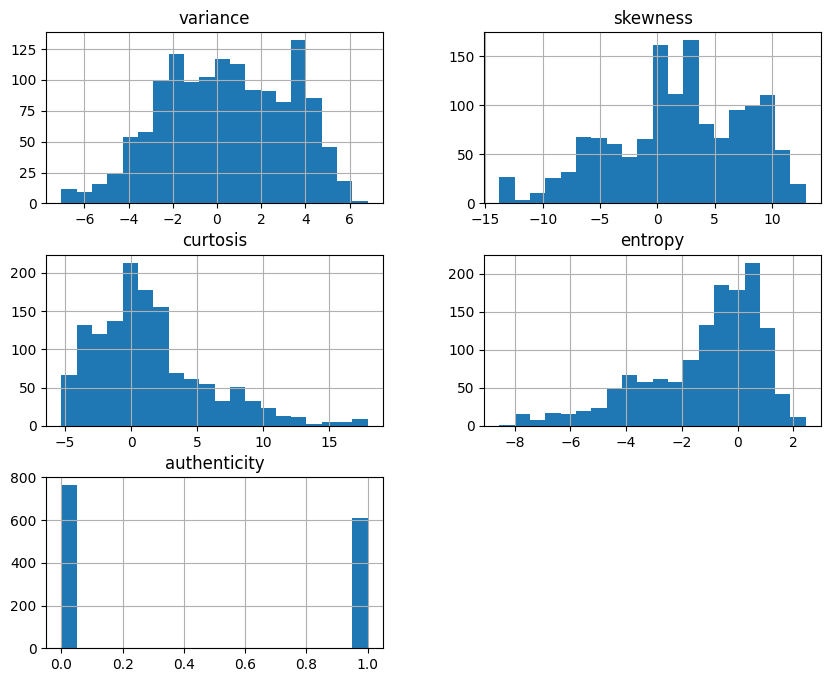

In [22]:

df.hist(figsize=(10, 8), bins=20)

plt.show()

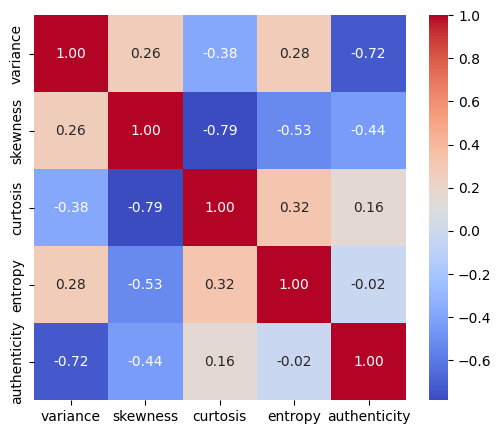

In [30]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

<Axes: xlabel='variance', ylabel='skewness'>

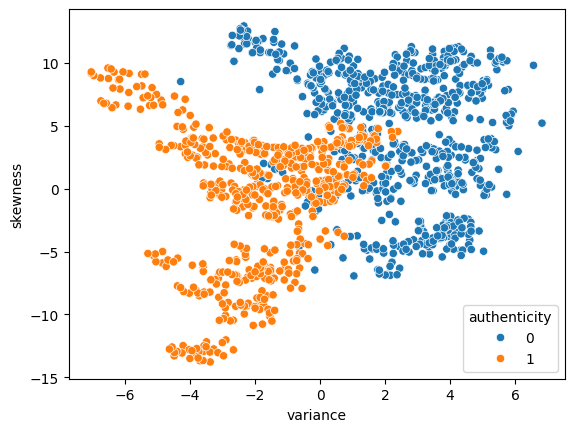

In [48]:
sns.scatterplot(data=df, x='variance', y='skewness', hue='authenticity')

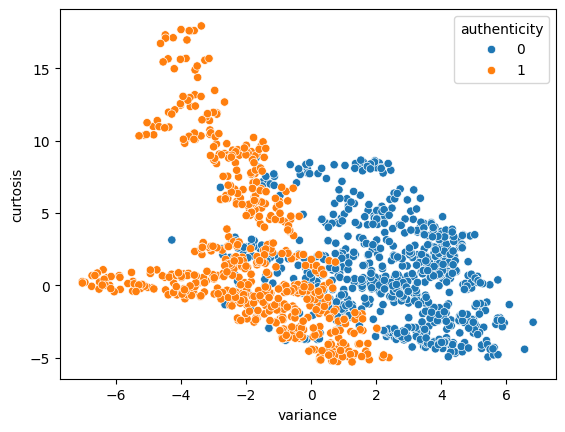

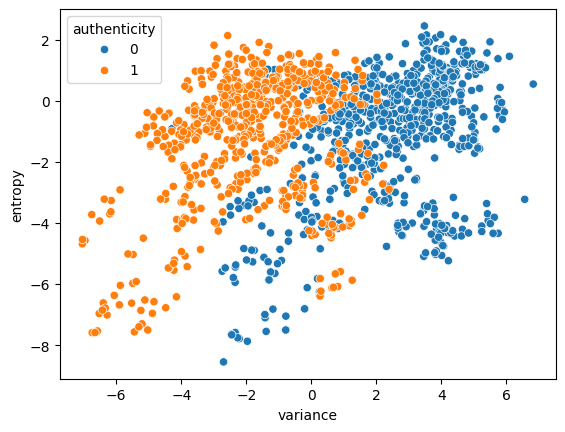

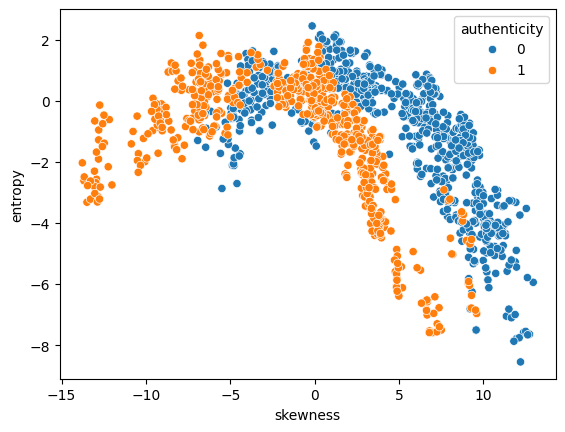

In [50]:
sns.scatterplot(data=df, x='variance', y='curtosis', hue='authenticity')
plt.show()

sns.scatterplot(data=df, x='variance', y='entropy', hue='authenticity')
plt.show()

sns.scatterplot(data=df, x='skewness', y='entropy', hue='authenticity')
plt.show()

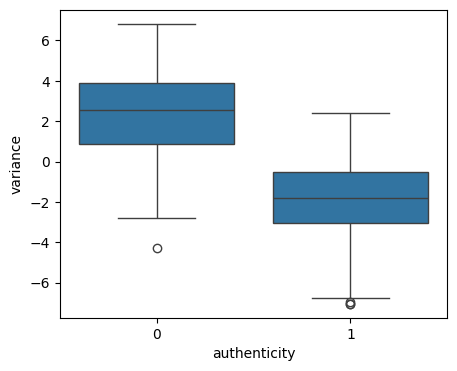

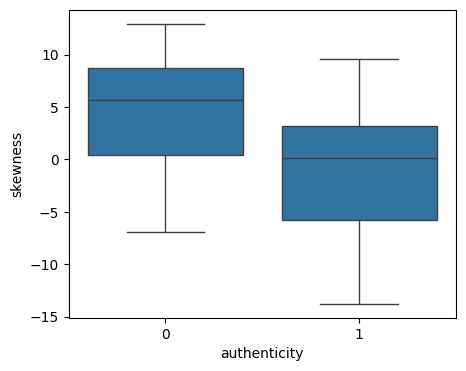

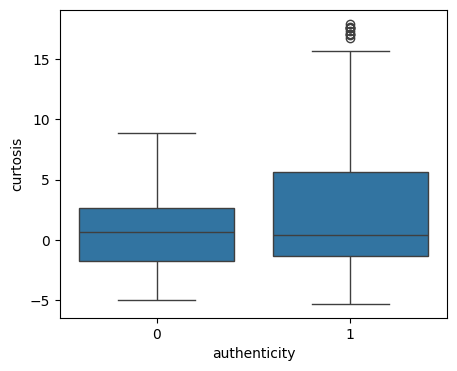

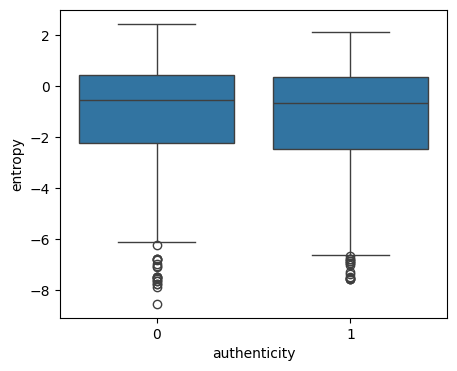

In [33]:
features = ['variance', 'skewness', 'curtosis', 'entropy']

for feature in features:
    plt.figure(figsize=(5,4))
    sns.boxplot(x='authenticity', y=feature, data=df)
    plt.show()

In [36]:
scaler=StandardScaler()
df=scaler.fit_transform(df)

In [39]:
X = df[:, :4]
y = df[:, 4]

In [53]:
X = df.iloc[:, :-1]
Y = df.iloc[:, -1]

In [54]:
X = scaler.fit_transform(X)

In [55]:
print(Y)

0       0
1       0
2       0
3       0
4       0
       ..
1367    1
1368    1
1369    1
1370    1
1371    1
Name: authenticity, Length: 1372, dtype: int64


In [59]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

In [60]:
print(len(Y_train))

1097


In [61]:
print(len(Y_test))

275


In [62]:
print(len(X_test))

275


In [65]:
print(len(X_train))

1097


In [66]:
weights = [1.0, 0.4, 0.2, 0.01]
bias=0

In [68]:
def act_step(x):
    if x >= 0:
        return 1
    else:
        return 0

In [96]:
epochs = 100
learning_rate = 0.001

best_misclassified = float('inf')
best_weights = None
best_bias = None
best_epoch = 0

for i in range(epochs):
  misclassified=0

  for j in range(len(X_train)):

    pre_activated=weights[0]*X_train[j][0]+weights[1]*X_train[j][1]+weights[2]*X_train[j][2]+weights[3]*X_train[j][3]+bias
    Y_pred=act_step(pre_activated)
    if Y_pred!=Y_train[j]:
      misclassified+=1
    error = Y_train[j] - Y_pred
    for k in range(4):
      weights[k] += learning_rate * error * X_train[j][k]
    bias += learning_rate * error
  if misclassified < best_misclassified:
      best_misclassified = misclassified
      best_weights = weights.copy()
      best_bias = bias
      best_epoch = i + 1
  print(f"Epoch {i+1}")
  print(f"Misclassified Samples : {misclassified}")
  print(f"Weights : {weights}")
  print(f"Bias : {bias}")
print("\nBest Model")
print(f"Epoch: {best_epoch}")
print(f"Misclassified Samples: {best_misclassified}")
print(f"Weights: {best_weights}")
print(f"Bias: {best_bias}")

Epoch 1
Misclassified Samples : 9
Weights : [np.float64(-0.3994338140554126), np.float64(-0.42404901962351105), np.float64(-0.38648612928933757), np.float64(-0.031458748080924505)]
Bias : -0.20700000000000002
Epoch 2
Misclassified Samples : 9
Weights : [np.float64(-0.39825733759285586), np.float64(-0.4236102312766389), np.float64(-0.3893388850161884), np.float64(-0.030728780451043908)]
Bias : -0.20400000000000001
Epoch 3
Misclassified Samples : 9
Weights : [np.float64(-0.3970808611302991), np.float64(-0.4231714429297667), np.float64(-0.39219164074303925), np.float64(-0.02999881282116331)]
Bias : -0.201
Epoch 4
Misclassified Samples : 9
Weights : [np.float64(-0.39590438466774236), np.float64(-0.42273265458289455), np.float64(-0.3950443964698901), np.float64(-0.029268845191282714)]
Bias : -0.198
Epoch 5
Misclassified Samples : 9
Weights : [np.float64(-0.39629917136119086), np.float64(-0.4237515831025195), np.float64(-0.3946936867113565), np.float64(-0.02925184121287052)]
Bias : -0.195
Ep

In [76]:
Y_train = Y_train.to_numpy()
Y_test = Y_test.to_numpy()

In [97]:
Y_test_pred = []

for i in range(len(X_test)):
    net = (
        best_weights[0]*X_test[i][0] +
        best_weights[1]*X_test[i][1] +
        best_weights[2]*X_test[i][2] +
        best_weights[3]*X_test[i][3] +
        best_bias
    )

    Y_test_pred.append(act_step(net))

In [98]:
TP = TN = FP = FN = 0

for i in range(len(Y_test)):
    if Y_test[i] == 1 and Y_test_pred[i] == 1:
        TP += 1
    elif Y_test[i] == 0 and Y_test_pred[i] == 0:
        TN += 1
    elif Y_test[i] == 0 and Y_test_pred[i] == 1:
        FP += 1
    elif Y_test[i] == 1 and Y_test_pred[i] == 0:
        FN += 1


In [99]:
precision = TP / (TP + FP) if (TP + FP) != 0 else 0

recall = TP / (TP + FN) if (TP + FN) != 0 else 0

f1_score = (
    2 * precision * recall / (precision + recall)
    if (precision + recall) != 0
    else 0
)

In [100]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

precision = TP / (TP + FP)

recall = TP / (TP + FN)

f1_score = 2 * precision * recall / (precision + recall)

In [101]:
print("Confusion Matrix")
print([[TN, FP],
       [FN, TP]])

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1_score:.4f}")

Confusion Matrix
[[146, 2], [2, 125]]
Accuracy : 0.9855
Precision: 0.9843
Recall   : 0.9843
F1-score : 0.9843
